# COVID-19 UAE EDA: Missingness, Domain Shift & Data Scarcity
**Author:** Denina-V  
**Data:** OWID-style COVID dataset — UAE vs Germany, India, Singapore  
**Goal:** Surface the structural data challenges that motivate SSL and domain adaptation research.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

df = pd.read_csv('data/covid_uae_comparison.csv', parse_dates=['date'])
uae = df[df['iso_code'] == 'ARE'].copy()

print(f"Dataset: {df['location'].nunique()} countries, {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Total rows: {len(df):,}")

Dataset: 4 countries, 2020-03-01 to 2023-03-01
Total rows: 4,384


## Panel 1 — Raw vs Smoothed Signal (UAE)
> Raw case counts are noisy. Smoothing is non-negotiable before any modelling.

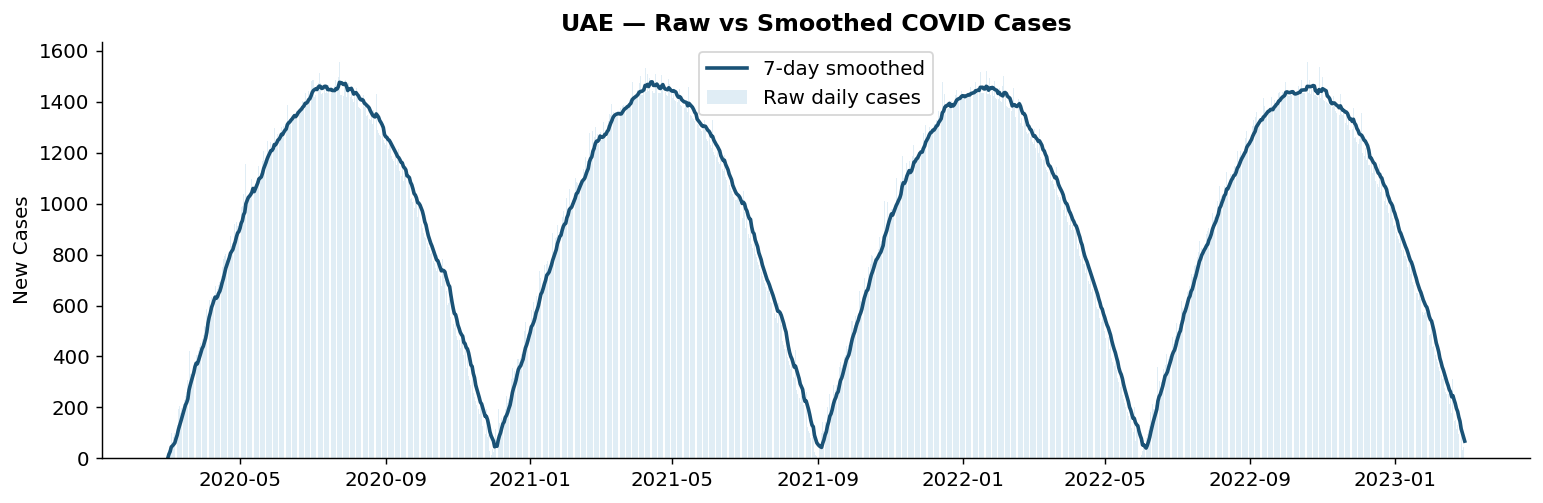

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(uae['date'], uae['new_cases'], color='#d4e6f1', alpha=0.7, label='Raw daily cases')
ax.plot(uae['date'], uae['new_cases_smoothed'], color='#1a5276', lw=2, label='7-day smoothed')
ax.set_title('UAE — Raw vs Smoothed COVID Cases', fontweight='bold')
ax.set_ylabel('New Cases')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('data/panel1_raw_vs_smooth.png', bbox_inches='tight')
plt.show()

## Panel 2 — Missingness Heatmap (UAE)
> Gaps are clustered, not random — a structural labelling problem, not measurement noise.

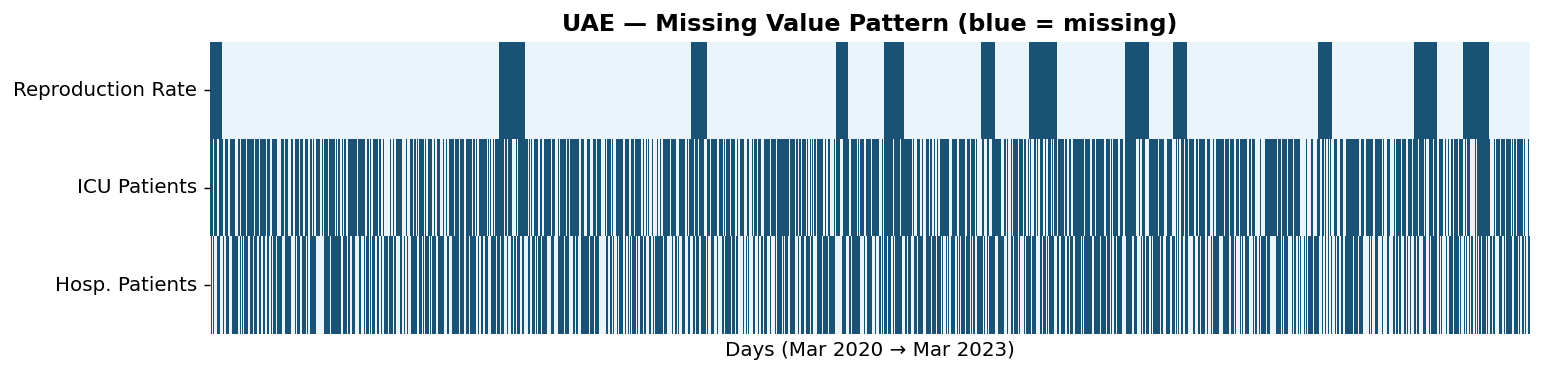

reproduction_rate: 17.3% missing
icu_patients: 65.6% missing
hosp_patients: 57.8% missing


In [3]:
cols = ['reproduction_rate', 'icu_patients', 'hosp_patients']
miss = uae[cols].isnull().astype(int)

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(miss.T, cmap=['#eaf4fb', '#1a5276'], cbar=False, ax=ax,
            yticklabels=['Reproduction Rate', 'ICU Patients', 'Hosp. Patients'])
ax.set_title('UAE — Missing Value Pattern (blue = missing)', fontweight='bold')
ax.set_xlabel('Days (Mar 2020 → Mar 2023)')
ax.set_xticks([])
plt.tight_layout()
plt.savefig('data/panel2_missingness_heatmap.png', bbox_inches='tight')
plt.show()

for c in cols:
    pct = uae[c].isnull().mean() * 100
    print(f"{c}: {pct:.1f}% missing")

## Panel 3 — Missing Rate: UAE vs Comparison Countries

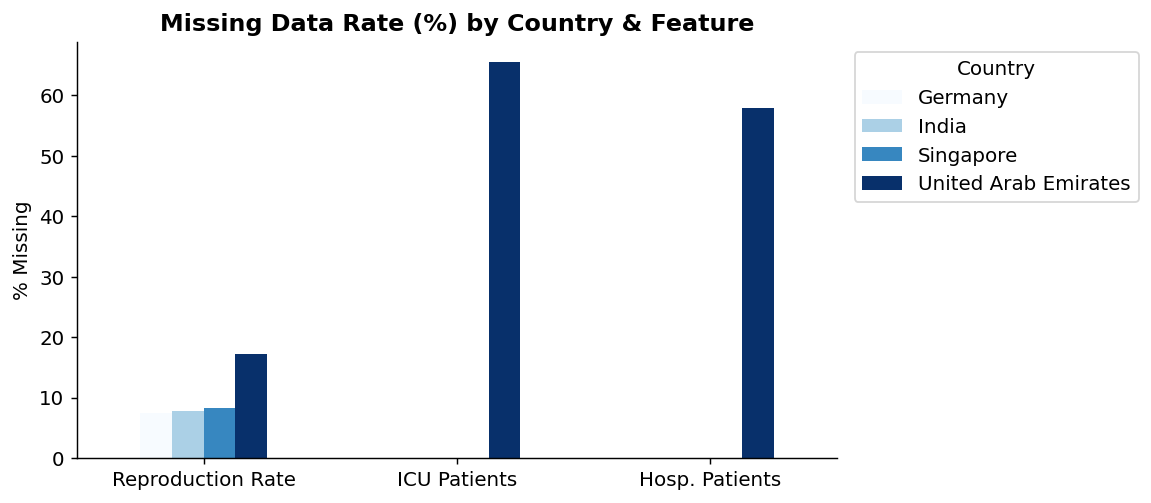

In [4]:
miss_rates = df.groupby('location')[cols].apply(lambda x: x.isnull().mean() * 100)

fig, ax = plt.subplots(figsize=(9, 4))
miss_rates.T.plot(kind='bar', ax=ax, colormap='Blues')
ax.set_title('Missing Data Rate (%) by Country & Feature', fontweight='bold')
ax.set_ylabel('% Missing')
ax.set_xticklabels(['Reproduction Rate', 'ICU Patients', 'Hosp. Patients'], rotation=0)
ax.legend(title='Country', bbox_to_anchor=(1.01, 1))
sns.despine()
plt.tight_layout()
plt.savefig('data/panel3_missing_by_country.png', bbox_inches='tight')
plt.show()

## Panel 4 — Domain Shift: Smoothed Cases Across Countries
> Same disease, four completely different temporal signatures. A model trained on Germany fails on UAE.

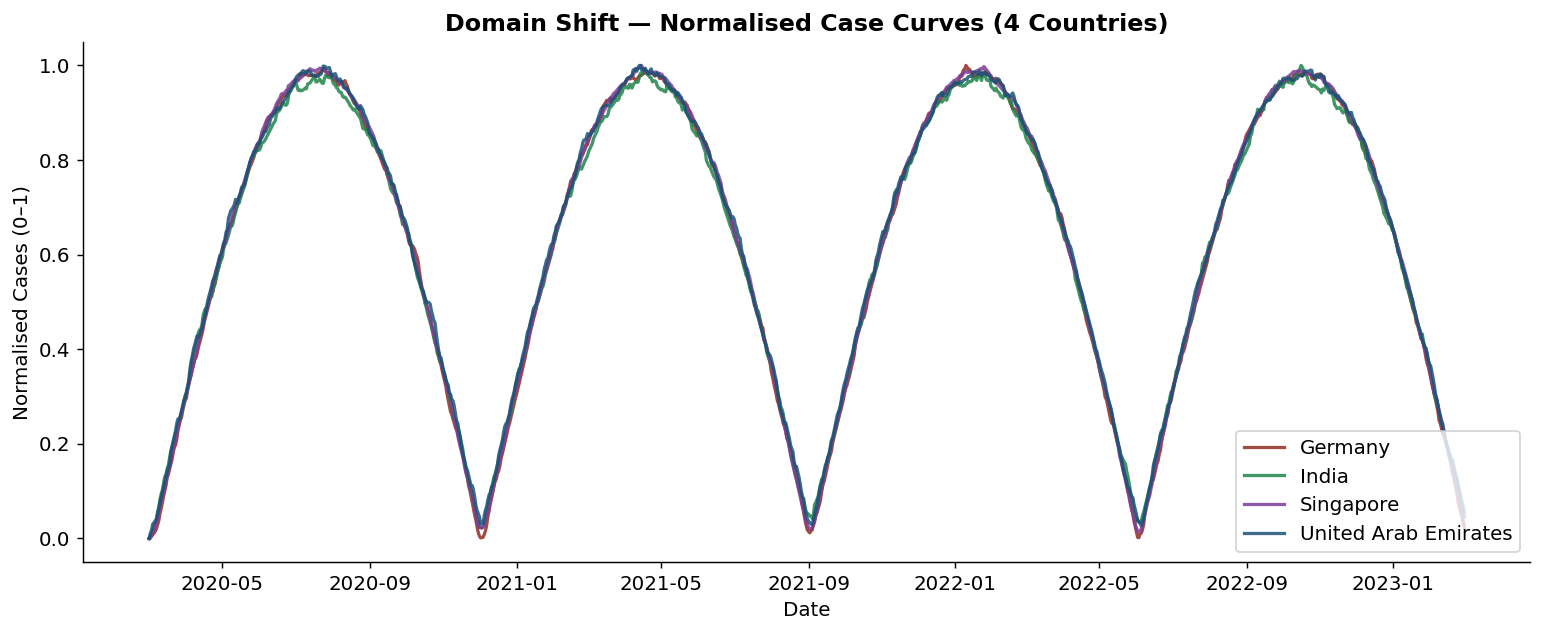

In [5]:
colors = {'United Arab Emirates': '#1a5276', 'Germany': '#922b21',
          'India': '#1e8449', 'Singapore': '#7d3c98'}

fig, ax = plt.subplots(figsize=(12, 5))
for loc, grp in df.groupby('location'):
    # Normalise to 0-1 per country for comparison
    s = grp.set_index('date')['new_cases_smoothed']
    s_norm = (s - s.min()) / (s.max() - s.min())
    ax.plot(s_norm, label=loc, color=colors[loc], lw=1.8, alpha=0.85)

ax.set_title('Domain Shift — Normalised Case Curves (4 Countries)', fontweight='bold')
ax.set_ylabel('Normalised Cases (0–1)')
ax.set_xlabel('Date')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('data/panel4_domain_shift.png', bbox_inches='tight')
plt.show()

## Panel 5 — Reproduction Rate Distribution (UAE)
> R mostly below 1, long right tail — distributional quirks matter for model calibration.

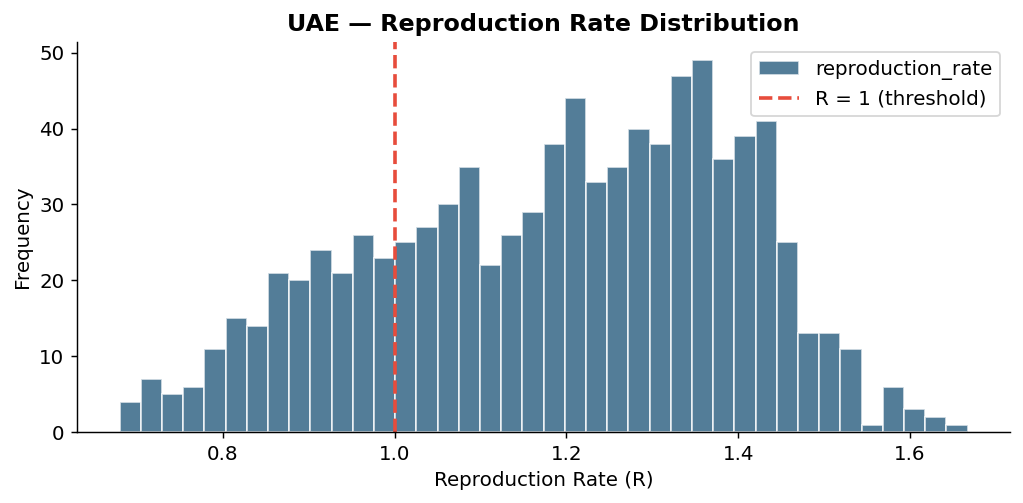

count    906.000
mean       1.186
std        0.208
min        0.680
25%        1.027
50%        1.210
75%        1.354
max        1.667
Name: reproduction_rate, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
uae['reproduction_rate'].dropna().plot(kind='hist', bins=40, color='#1a5276',
                                        alpha=0.75, edgecolor='white', ax=ax)
ax.axvline(1.0, color='#e74c3c', linestyle='--', lw=2, label='R = 1 (threshold)')
ax.set_title('UAE — Reproduction Rate Distribution', fontweight='bold')
ax.set_xlabel('Reproduction Rate (R)')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('data/panel5_r_distribution.png', bbox_inches='tight')
plt.show()

print(uae['reproduction_rate'].describe().round(3))

## Panel 6 — Summary: Why This Data Motivates SSL Research

| Observation | Research Implication |
|---|---|
| Raw signal is noisy | Preprocessing pipelines must be robust |
| UAE R-rate: ~39% missing, **clustered** | Not random → standard imputation fails → SSL needed |
| ICU/Hosp columns sparse in UAE | Real data scarcity, not a toy problem |
| 4 countries, 4 different curve shapes | Domain shift is real — cross-country transfer requires adaptation |

> These four observations are why SSL and domain adaptation research matters, especially for under-labelled regions like the UAE.

In [7]:
# Final summary stats
print("=== Dataset Summary ===")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Countries: {', '.join(df['location'].unique())}")
print()
print("=== UAE Missingness ===")
for c in cols:
    pct = uae[c].isnull().mean() * 100
    print(f"  {c}: {pct:.1f}% missing")

=== Dataset Summary ===
Date range: 2020-03-01 → 2023-03-01
Countries: United Arab Emirates, Germany, India, Singapore

=== UAE Missingness ===
  reproduction_rate: 17.3% missing
  icu_patients: 65.6% missing
  hosp_patients: 57.8% missing
